# Single-population Hawkes with CUBIC φ, ALPHA KERNEL, NO RESET: pipeline vs simulation

Builder-generated companion to the linear+reset notebook.  Theory:

  - single population E of size 2
  - cubic transfer: `φ(v) = a·v³`
  - per-pair alpha filter `g[i,j]` (= (t/τ_g²) e^{-t/τ_g} H(t)) with timescales `taug[i,j]`
  - NO spike reset (voltage drifts continuously through spike events)

**Why this case is interesting.**  With `φ = a·v³` we get a nonzero
`φ''(v*) = 6·a·v*`, which introduces the cubic vertex `nt·δv·δv` and the quartic vertex `nt·δv·δv·δv` at
bigrade (1, 2).  This is the canonical cubic-Hawkes case — same
physics as `pipeline.theories.cubic_alpha_hawkes_2pop`, but loaded
from a builder-generated `.theory.py` file so we can iterate on the
theory definition without touching pipeline code.

**Theory file**: `theories/single_population_cubic_alpha_test.theory.py`  
**Simulator**:   `models.hawkes_sim_multipop_numba.sim_hawkes_multipop_cubic_alpha_numba`

**Modes supported** (set in the configuration cell):
- `k = 1, max_ell = 1` — tadpole 1-loop rate shift (bar chart).
- `k = 2, max_ell = 0` — tree-level `C^(2)(τ)` slice.
- `k = 2, max_ell = 1` — tree + 1-loop `C^(2)(τ)` slice.

## 1. Setup

In [1]:
%display latex
%matplotlib inline

import os, sys, time, importlib, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import os, sys
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before

# Shared demo engine (load_theory / Config / run / plot_cumulant).
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import nb_support as nb

# Pipeline (theory side)
from pipeline import compute_cumulants

# Simulation side — cubic-rate, no-reset variant.  Per-pair
# alpha filter, signed coupling matrix W — same plumbing as the other
# multipop sim variants.
from models.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_cubic_alpha_numba,
    build_sim_arrays,
    flat_index_of,
)
from models.cumulant_estimator import compute_kpoint_slice

## 2. Configuration

`fundamental` provides numerical values for every parameter in
`single_population_cubic_alpha_test.theory.py`.  Names match the
theory file: `Em`, `tau`, `a`, `w`, `taug`.

Pick `k` / `max_ell` for the comparison:
- `k=2, max_ell=0` — tree-level cross-cumulant (LNA prediction).
- `k=2, max_ell=1` — tree + 1-loop from the quad-φ cubic vertex.
- `k=1, max_ell=1` — tadpole shift to the mean rate.

In [2]:
fundamental = {
    'Em':   [0.8, 0.78],
    'tau':  [10.0, 9.0],
    'a':    [0.44, 0.44],
    'taug': [[2.0, 3.0], [1.0, 3.0]],
    'w':    [[0.25, 0.25], [0.2, 0.3]],
}

k        = 2
max_ell  = 0
# External fields — single-pop natural name is just 'n' (without
# a population suffix); the pipeline maps 'n' → internal 'dn'.
if k == 1:
    external_fields = [('n', 1)]
else:
    external_fields = [('n', 1), ('n', 2)]

tau_max  = 20.0
tau_step = 2.5

PARALLEL  = True
N_WORKERS = None

# ─── Grouped Phase J prototype (opt-in) ───────────────
# When True, groups typed diagrams by (parent prediagram,
# external_legs) and integrates the SUMMED integrand once per group
# instead of once per typed diagram.  Mathematically exact (bitwise
# cross-checked).
USE_GROUPED_PHASE_J = False

# ─── Polygon m=2 integrator (Stage 3a-full, phase-j-refactor branch) ──
# When True, m=2 subsets are integrated analytically via mode-
# expansion + closed-form ∫∫_polygon exp(α·s_0 + β·s_1) dA on a
# triangulated convex polytope, instead of scipy.nquad on the
# Sage-compiled closure.  Mathematically exact for rational
# propagators (no quadrature error); 5-100× faster.  Only fires
# when the diagram has m=2 subsets — that requires max_ell >= 1
# (tree-level k=2 collapses to m=0/1 only).
#
# Falls back to scipy.nquad silently for: non-local kernel
# diagrams, polygon empty/degenerate, mode-data extraction
# failures.  Toggle to False to A/B-compare against the scipy path.
USE_POLYGON_M2_INTEGRATOR = True

# ─── Causal-poset m≥3 integrator (Stage 3b, phase-j-refactor branch) ──
# When True, m≥3 subsets are integrated analytically via causal-
# poset decomposition: extract the partial order on integration
# variables from retardation constraints, enumerate linear extensions
# (topological sorts), and evaluate each chain simplex's nested
# exponential integral as a closed-form sum of 2^N terms.  Same
# correctness guarantees as the polygon path (exact for rational
# propagators).  Targets the m=3, m=4 subsets that dominated
# scipy.nquad time on quad-φ 1-loop diagrams.
#
# Falls back to scipy.nquad silently for: mixed/shifted retardation
# constraints, scalar lowers on multiple variables that disagree,
# and pole tuples that produce a degenerate β at any chain-simplex
# level (cumulative pole sums vanishing).
USE_POSET_INTEGRATOR = True

# ─── 1D interval integrator (Stage 4a-perdiag, 2026-05-15) ────────────
# When True, m=1 subsets are integrated analytically via closed-form
# ∫_L^U Σ_α C_α exp(λ_α·Δt) ds with exact ±∞ bound handling, instead
# of scipy.quad on the pole-residue closure.  Same correctness as the
# m=2 polygon path.  Toggle to False to A/B against scipy.quad on the
# m=1 subsets (typically the tree-level closure for k≥2 correlators).
USE_1D_INTEGRATOR = True

# ─── Numba-compiled chain simplex (Stage 4a, 2026-05-15) ──────────────
# When True, the m≥3 chain-simplex hot path dispatches to a
# @njit(cache=True) numba core operating on complex128 buffers.
# 6-12× speedup per call vs the pure-Python reference (micro-bench).
# No wall-time effect on m≤2 fixtures (they never enter the chain
# simplex); meaningful only on configs with m≥3 subsets — e.g.
# k=2 max_ell=1 or k=1 max_ell=2.  False forces the Python reference.
USE_NUMBA_CHAIN_SIMPLEX = True

# ─── ``simplify_full()`` in ``build_G_t_matrix`` (Stage 4a opt #2) ─────
# When False (default), skip the per-entry Maxima simplify_full pass
# on the smooth propagator matrix.  Flag name describes the BEHAVIOUR
# (run simplify), not the optimization (which is to skip it).
#
# Why False is the default
# ------------------------
# After Stage 4a opt #1 (commit 6d75869), the smooth matrix is read
# ONLY when a subset falls onto the residual SR + ``fast_callable``
# path.  For plain rational-propagator theories (linear/cubic φ,
# spike-reset, GTaS auto-cumulants, cortical Poisson noise) every
# subset is analytic-eligible — the smooth matrix is built then
# never queried.  The simplify pass was ~16% of integrate_diagram
# wall on k=2 max_ell=1 quad before the gate.  Measured wall savings
# with False on the regression fixtures: −19% to −41%.
#
# When True may pay back
# ----------------------
# ``NoiseSourceType`` vertices with a smooth kernel — Gaussian noise,
# any non-Dirac ``kernel_fn`` in ``correlated_noises`` — populate
# ``vertex_leg_time``.  Those diagrams force ``_analytic_eligible =
# False`` for every subset: the integrand picks up a non-rational
# factor ``K(τ_v)`` (e.g. ``exp(-τ²/2σ²)``) which the polygon /
# poset / interval closed forms cannot absorb.  The pipeline falls
# back to ``scipy.nquad`` on the JIT-compiled SR closure.  On THAT
# path the smooth matrix entries ARE consumed (multiplied into
# ``subset_factor``, expanded, fast_callable-compiled), so a clean-
# up upstream can collapse duplicate poles and shrink the JIT tree.
#
# Concrete example: a 4-pole 5-edge subset's distributed sum has
# 4⁵ = 1024 terms naively.  If simplify_full collapses two
# numerically-identical poles (Newton refinement sometimes produces
# these), the effective pole count drops to 3 and the JIT tree
# shrinks to 3⁵ = 243 — 4× smaller compile, smaller per-call walk.
# Whether the upstream Maxima cost recoups depends on how many
# ``NoiseSourceType`` subsets fire per pipeline call and how much
# pole-list redundancy there is.
#
# Benchmarking practice
# ---------------------
# When you bring NoiseSourceType / correlated_noises theories into
# the comparison sweep, run each config TWICE — once True, once
# False — and compare the ``Theory side took ...s`` line.  Cell C
# below also prints the ``fast_callable`` call count; that climbs
# into the hundreds for NoiseSourceType configs (Stage 4a opt #1
# short-circuit doesn't fire), and that's the population on which
# True is acting.  Keep a False "control" row to separate the
# "cost of Maxima" axis from the "benefit of cleaner SR input"
# axis.
USE_SIMPLIFY_FULL_IN_GT = False

# Simulation knobs.  Cubic rate is *very* sensitive to large v excursions than the linear variant; use a moderate T_sim and
# small dt_sim so the Poisson statistics resolve cleanly.
N_RUNS   = 4
T_sim    = float(2_000_000)
dt_sim   = 0.01            # Euler step
dt_bin   = 0.25            # binning resolution for the cumulant estimator

print(f'k={k}, max_ell={max_ell}, external_fields={external_fields}')
print(f'tau_max={tau_max}, tau_step={tau_step}')
print(f'PARALLEL={PARALLEL}, N_WORKERS={N_WORKERS}, '
      f'USE_GROUPED_PHASE_J={USE_GROUPED_PHASE_J}')
print(f'Phase J analytic flags:')
print(f'  USE_POLYGON_M2_INTEGRATOR = {USE_POLYGON_M2_INTEGRATOR}')
print(f'  USE_POSET_INTEGRATOR      = {USE_POSET_INTEGRATOR}')
print(f'  USE_1D_INTEGRATOR         = {USE_1D_INTEGRATOR}')
print(f'  USE_NUMBA_CHAIN_SIMPLEX   = {USE_NUMBA_CHAIN_SIMPLEX}')
print(f'  USE_SIMPLIFY_FULL_IN_GT   = {USE_SIMPLIFY_FULL_IN_GT}')
print(f'N_RUNS={N_RUNS}, T_sim={T_sim:.0g}, dt_sim={dt_sim}, dt_bin={dt_bin}')


k=2, max_ell=0, external_fields=[('n', 1), ('n', 2)]
tau_max=20.0000000000000, tau_step=2.50000000000000
PARALLEL=True, N_WORKERS=None, USE_GROUPED_PHASE_J=False
Phase J analytic flags:
  USE_POLYGON_M2_INTEGRATOR = True
  USE_POSET_INTEGRATOR      = True
  USE_1D_INTEGRATOR         = True
  USE_NUMBA_CHAIN_SIMPLEX   = True
  USE_SIMPLIFY_FULL_IN_GT   = False
N_RUNS=4, T_sim=2e+06, dt_sim=0.0100000000000000, dt_bin=0.250000000000000


## 3. Load the theory file

Single population E of size 2, fields `n` and `v`, cubic
transfer `φ(v) = a·v³`, no spike reset.  Auto-response names are
`nt`, `vt`; auto-saddles are `nstar`, `vstar`.  The MF equations
are `vstar = Em + Σ w·g·nstar` (with `g` integrating to 1) and
`nstar = phi(vstar) = a·vstar³`.

In [3]:
THEORY_NAME = 'single_population_cubic_alpha_test'

# Load through the shared engine (single source of truth for theories).
model, theory_mod = nb.load_theory(THEORY_NAME)

print(f'Loaded theory: {model["name"]!r}')
print(f'Populations: {[(p["name"], p["size"]) for p in model["populations"]]}')
print(f'Fields (physical): '
      f'{[f["name"] for f in model["physical_fields"]]}')
print(f'Kernels: {[k["name"] for k in model["kernels"]]}')
print(f'Functions: '
      f'{[(fn["name"], fn.get("args")) for fn in model["functions"]]}')

Loaded theory: 'Single population Cubic Alpha Test'
Populations: [('E', 2)]
Fields (physical): ['dn', 'dv']
Kernels: ['g']
Functions: [('phi', None)]


## 3.5 Diagnostic: source + vertex types

Prints every source vertex and interaction vertex with bigrade,
leg structure, raw + `simplify_full()`-cleaned coefficient.  For
cubic φ without reset you should see:

- `(k, 0)` sources for k=2..taylor with coeff `∝ a·vstar²`
- `(1, 2)` cubic vertex with coeff `-a` — the curvature term that
  drives 1-loop corrections in this theory.
- NO `(1, 2)` vertex with coeff `∝ tau` (that would be a spike-reset
  signature, which this theory does NOT have).

In [4]:
from msrjd.core.field_theory import FieldTheory
from msrjd.core.vertices import (extract_source_types,
                                  extract_vertex_types,
                                  NoiseSourceType)
from sage.all import SR

_taylor_order = max(k + 2 * max_ell, 4)
_ft_diag = FieldTheory(model, taylor_order=_taylor_order)
_ft_diag.expand()
print(f'FieldTheory.expand done (taylor_order={_taylor_order})')

_sources = extract_source_types(_ft_diag)
_vertices = extract_vertex_types(_ft_diag)
print(f'\n  {len(_sources)} source vertices, {len(_vertices)} interaction vertices')

from collections import Counter
src_bigrades = Counter(s.bigrade for s in _sources)
vt_bigrades  = Counter(v.bigrade for v in _vertices)
print(f'\n  Source bigrades:      {dict(sorted(src_bigrades.items()))}')
print(f'  Interaction bigrades: {dict(sorted(vt_bigrades.items()))}')

def _coeff_diag(label, idx, obj):
    raw = SR(obj.coefficient)
    raw_str = str(raw)
    try:
        simp = raw.simplify_full()
    except Exception:
        simp = raw
    simp_str = str(simp)
    legs_str = (f'resp={obj.response_legs}'
                + (f', phys={obj.physical_legs}'
                   if hasattr(obj, 'physical_legs') else ''))
    print(f'  {label}[{idx}]  bigrade={obj.bigrade}  {legs_str}')
    print(f'    raw  ({len(raw_str):4d} chars): {raw_str}')
    if simp_str != raw_str:
        delta = len(raw_str) - len(simp_str)
        sign  = '−' if delta > 0 else '+'
        print(f'    simp ({len(simp_str):4d} chars, {sign}{abs(delta):3d}): {simp_str}')
    residual = []
    for v in raw.variables():
        sname = str(v)
        if sname.startswith(('phi', 'z_g_', '_v_mf_', '_phi_arg_')):
            residual.append(sname)
    if residual:
        print(f'    ⚠ residual formal symbols: {sorted(set(residual))}')

print('\n=== Source vertices ===')
for idx, src in enumerate(_sources):
    _coeff_diag('src', idx, src)

print('\n=== Interaction vertex types ===')
for idx, vt in enumerate(_vertices):
    _coeff_diag('vt ', idx, vt)

FieldTheory.expand done (taylor_order=4)

  6 source vertices, 10 interaction vertices

  Source bigrades:      {(2, 0): 2, (3, 0): 2, (4, 0): 2}
  Interaction bigrades: {(1, 2): 2, (1, 3): 2, (2, 1): 2, (2, 2): 2, (3, 1): 2}

=== Source vertices ===
  src[0]  bigrade=(4, 0)  resp=[('nt', 1), ('nt', 1), ('nt', 1), ('nt', 1)]
    raw  (  17 chars): -1/24*a1*vstar1^3
  src[1]  bigrade=(4, 0)  resp=[('nt', 2), ('nt', 2), ('nt', 2), ('nt', 2)]
    raw  (  17 chars): -1/24*a2*vstar2^3
  src[2]  bigrade=(3, 0)  resp=[('nt', 1), ('nt', 1), ('nt', 1)]
    raw  (  16 chars): -1/6*a1*vstar1^3
  src[3]  bigrade=(3, 0)  resp=[('nt', 2), ('nt', 2), ('nt', 2)]
    raw  (  16 chars): -1/6*a2*vstar2^3
  src[4]  bigrade=(2, 0)  resp=[('nt', 1), ('nt', 1)]
    raw  (  16 chars): -1/2*a1*vstar1^3
  src[5]  bigrade=(2, 0)  resp=[('nt', 2), ('nt', 2)]
    raw  (  16 chars): -1/2*a2*vstar2^3

=== Interaction vertex types ===
  vt [0]  bigrade=(3, 1)  resp=[('nt', 1), ('nt', 1), ('nt', 1)], phys=[('dv', 1)]


## 3.6 Performance diagnostics (optional)

These cells help isolate slow paths.  Skip on production runs.

**Cell A** A/Bs parallel vs serial on a tiny `k=1, max_ell=1`
sub-config (~30s) so you can confirm `multiprocessing.Pool` is
actually firing and that bit-identity holds.

**Cell B** runs `cProfile` over a 2-point τ-grid with your
current `k`, `max_ell`.  Prints the top 40 frames by cumulative
time and writes a `.prof` file you can open with `snakeviz`.

**Cell C** runs the analytic-path runtime counters: distinguishes
intent (the `subset_evaluators` labels that get set at setup time)
from runtime (whether the analytic path actually completed or
silently fell back to scipy.nquad).  Lightweight (~half a normal
run).  Use this to confirm Stage 3b-extended is firing on m≥3
subsets after a kernel restart.

If `max_ell=2` and a full grid is too slow to wait for, run Cell B
with `_PROF_MAX_ELL` set to the current value — the 2-point τ-grid
keeps it bounded even when the per-τ cost is high.


In [5]:
# === Cell A: parallelization sanity check ===
# Times parallel vs serial on a quick (k=1, max_ell=1) sub-config
# so we can confirm multiprocessing.Pool is actually firing on this
# machine.  Should take ~30 seconds total.

# Disabled by default — flip ``False`` → ``True`` to run.
if False:
    import os, time
    import numpy as np
    from msrjd.integration.time_domain import final_integral as _fi

    # Wire analytic-integrator flags first.
    _fi.USE_POLYGON_M2_INTEGRATOR = USE_POLYGON_M2_INTEGRATOR
    _fi.USE_POSET_INTEGRATOR      = USE_POSET_INTEGRATOR
    _fi.USE_1D_INTEGRATOR         = USE_1D_INTEGRATOR
    _fi.USE_NUMBA_CHAIN_SIMPLEX   = USE_NUMBA_CHAIN_SIMPLEX
    from msrjd.integration.time_domain import propagator_td as _pt
    _pt.USE_SIMPLIFY_FULL_IN_GT   = USE_SIMPLIFY_FULL_IN_GT

    print(f'os.cpu_count()                = {os.cpu_count()}')
    print(f'N_WORKERS (None ⇒ auto)       = {N_WORKERS}')
    print()

    # Small config: enough τ points to fill the worker pool.
    _diag_cfg = dict(
        model               = model,
        k                   = 1,
        max_ell             = 1,
        fundamental         = fundamental,
        external_fields     = [('n', 1)],
        tau_max             = 5.0,
        tau_step            = 0.5,           # 11 τ points
        n_workers           = N_WORKERS,
        verbose             = False,
        use_grouped_phase_j = False,
    )

    t0 = time.perf_counter()
    _th_ser = compute_cumulants(**_diag_cfg, parallel=False)
    _t_ser = time.perf_counter() - t0

    t0 = time.perf_counter()
    _th_par = compute_cumulants(**_diag_cfg, parallel=True)
    _t_par = time.perf_counter() - t0

    _n_tau = len(_th_ser['tau_grid'])
    _n_cpu = os.cpu_count() or 1
    _ideal = min(_n_cpu, _n_tau)
    _speedup = _t_ser / max(_t_par, 1e-9)
    _diff = np.max(np.abs(_th_par['C_tau'] - _th_ser['C_tau']))

    print(f'serial    : {_t_ser:6.2f}s   ({_n_tau} τ points)')
    print(f'parallel  : {_t_par:6.2f}s')
    print(f'speedup   : {_speedup:.2f}x   '
          f'(ideal ≈ min(cpu_count={_n_cpu}, n_tau={_n_tau}) = {_ideal})')
    print(f'|C_par − C_ser|_max = {_diff:.2e}  '
          f'{"OK" if _diff < 1e-12 else "⚠ bit-identity broken"}')
    print()
    if _speedup < 1.5:
        print('⚠  parallelism does not seem to be firing.  Common causes:')
        print('   • total_tasks < max(4, 2*n_workers): too small to amortise')
        print('     pool setup — see pipeline.total_C_batch serial fast path.')
        print('   • fork start method rejected (rare on macOS/Linux).')
        print('   • PARALLEL=False at the top level (check this notebook).')
    elif _speedup < _ideal * 0.5:
        print(f'⚠  speedup ({_speedup:.1f}x) is well below ideal '
              f'({_ideal}x) — pool setup + GIL contention from outside')
        print('   workers may be dominating.  Worth a profile.')
    else:
        print(f'✓ parallelism healthy: {_speedup:.1f}x of {_ideal}x ideal.')


In [6]:
# === Cell B: cProfile k, max_ell on a 2-point τ grid ===
# Profiles the SERIAL path (cProfile can't see worker processes).
# Uses the current k / max_ell so we see the actual bottleneck
# you care about.  The 2-point grid keeps wall time bounded even
# at 2-loop.

# Disabled by default — flip ``False`` → ``True`` to run.
if False:
    import cProfile, pstats, io, time

    _PROF_K       = k
    _PROF_MAX_ELL = max_ell
    print(f'Profiling k={_PROF_K}, max_ell={_PROF_MAX_ELL}, 1 τ point '
          f'(serial; cProfile does not see workers)...')

    _pr = cProfile.Profile()
    _t0 = time.perf_counter()
    _pr.enable()
    _th_prof = compute_cumulants(
        model               = model,
        k                   = _PROF_K,
        max_ell             = _PROF_MAX_ELL,
        fundamental         = fundamental,
        external_fields     = external_fields,
        tau_max             = 0.0,           # → grid is [0.0]
        tau_step            = 1.0,           # 1 τ point total
        parallel            = False,
        verbose             = False,
        use_grouped_phase_j = USE_GROUPED_PHASE_J,
    )
    _pr.disable()
    print(f'Profile wall time (serial, 1 τ point): '
          f'{time.perf_counter() - _t0:.1f}s')
    print()

    _buf = io.StringIO()
    pstats.Stats(_pr, stream=_buf).sort_stats('cumulative').print_stats(40)
    print(_buf.getvalue())

    _prof_path = 'phase_j_profile.prof'
    _pr.dump_stats(_prof_path)
    print(f'Saved {_prof_path} — open with `snakeviz {_prof_path}` for '
          f'a flame view.')
    print()
    print('What to look for in the top-40 cumulative list:')
    print("  • '_integrate_nd_polytope' / scipy quadpack dominating")
    print('    ⇒ degenerate-β closed form is the right next step.')
    print("  • '_build_fast_subset_evaluator_from_modes' dominating")
    print('    ⇒ cache compiled callables per subset signature.')
    print("  • 'SR.subs' / 'fast_callable' compile dominating")
    print('    ⇒ Stage 4 subset-signature plan cache pays off.')
    print("  • '_enumerate_pole_tuples' or polygon loop dominating")
    print('    ⇒ vectorise the multi-index loop with numpy.')


In [7]:
# === Cell C: analytic-path runtime counters ===
# The `subset_evaluators` breakdown in cell 13 reports INTENT (the
# evaluator label set at subset setup time), not whether the analytic
# path actually completed at runtime.  When an analytic path returns
# None (degenerate β past the polynomial extension, mixed constraint,
# maximality failure, etc.), the closure silently falls back to
# scipy.nquad — same label, very different wall time.
#
# This cell zeros the runtime counters, runs a single-τ pass with your
# current k / max_ell, and prints what actually fired.  Mirrors the
# normal pipeline call but with parallel=False and a 1-point
# τ-grid (tau_max=0.0) so it's bounded.

# Disabled by default — flip ``False`` → ``True`` to run.
if False:
    from msrjd.integration.time_domain import final_integral as _fi
    import time

    _fi.USE_POLYGON_M2_INTEGRATOR = USE_POLYGON_M2_INTEGRATOR
    _fi.USE_POSET_INTEGRATOR      = USE_POSET_INTEGRATOR
    _fi.USE_1D_INTEGRATOR         = USE_1D_INTEGRATOR
    _fi.USE_NUMBA_CHAIN_SIMPLEX   = USE_NUMBA_CHAIN_SIMPLEX
    from msrjd.integration.time_domain import propagator_td as _pt
    _pt.USE_SIMPLIFY_FULL_IN_GT   = USE_SIMPLIFY_FULL_IN_GT
    _fi._reset_runtime_counters()

    # k=1 needs exactly 1 external field; k≥2 needs k of them.
    _DIAG_EXT = ([('n', 1)] if k == 1
                 else [('n', i + 1) for i in range(k)])

    print(f'Running diagnostic: k={k}, max_ell={max_ell}, 1 τ point '
          f'(serial; counters track every analytic-path decision)...')
    _t0 = time.perf_counter()
    _th_diag = compute_cumulants(
        model               = model,
        k                   = k,
        max_ell             = max_ell,
        fundamental         = fundamental,
        external_fields     = _DIAG_EXT,
        tau_max             = 0.0,           # → grid is [0.0]
        tau_step            = 1.0,           # 1 τ point total
        parallel            = False,
        verbose             = False,
        use_grouped_phase_j = USE_GROUPED_PHASE_J,
    )
    _wall = time.perf_counter() - _t0
    print(f'Wall time (serial, single-τ): {_wall:.1f}s')
    print()

    # Pretty-print counters in grouped form for readability.
    _c = dict(_fi._RUNTIME_COUNTERS)
    print('=== Runtime path counters ===')
    print(f'  m=1 interval path:  attempted={_c["interval_attempted"]:>6d}'
          f'  none={_c["interval_returned_none"]:>6d}')
    print(f'  m=2 polygon  path:  attempted={_c["polygon_attempted"]:>6d}'
          f'  none={_c["polygon_returned_none"]:>6d}')
    print(f'  m≥3 poset    path:  attempted={_c["poset_attempted"]:>6d}'
          f'  none={_c["poset_returned_none_total"]:>6d}')
    print('    breakdown of m≥3 None returns:')
    print(f'      extract returned None:   '
          f'{_c["poset_extract_returned_none"]:>6d}')
    print(f'      consistent_lower failed: '
          f'{_c["poset_consistent_lower_failed"]:>6d}')
    print(f'      maximality check failed: '
          f'{_c["poset_maximality_failed"]:>6d}')
    print(f'      chain fast → polynomial: '
          f'{_c["chain_simplex_fast_returned_none"]:>6d}')
    print(f'      chain polynomial None:   '
          f'{_c["chain_simplex_polynomial_returned_none"]:>6d}')
    print()
    print(f'  scipy.nquad fallback:  m=1={_c["scipy_nquad_called_m1"]:>6d}'
          f'   m=2={_c["scipy_nquad_called_m2"]:>6d}'
          f'   m≥3={_c["scipy_nquad_called_mge3"]:>6d}')
    print()

    # Cheap diagnosis cribsheet.
    _n_m3 = _c['poset_attempted']
    _n_fb = _c['scipy_nquad_called_mge3']
    if _n_m3 == 0:
        print('No m≥3 subsets exercised at this (k, max_ell).')
    elif _n_fb == 0:
        print(f'✓ All {_n_m3} m≥3 subsets handled analytically — '
              f'Stage 3b/3b-extended is doing its job.')
        print(f'  If the run is still slow, the bottleneck is the analytic '
              f'path itself (numba/numpy vectorization next).')
    elif _n_fb >= _n_m3 * 0.9:
        print(f'⚠ Nearly all m≥3 subsets ({_n_fb}/{_n_m3}) silently fell '
              f'back to scipy.nquad.  See breakdown above for the dominant')
        print('  None-return cause.')
    else:
        print(f'Partial coverage: {_n_m3 - _n_fb}/{_n_m3} analytic, '
              f'{_n_fb}/{_n_m3} scipy fallback.  Mixed; check breakdown.')


## 4. Theory side — one pipeline call

Runs the full MSR-JD chain.  At `max_ell=0` the tree-level
$C^{(2)}(\tau)$ matches the LNA prediction (correct gain
$\phi'(v^*) = 3 a v^{*2}$); at `max_ell=1` the 1-loop contribution
from the cubic vertex (coeff $-a$) is added.

In [8]:
# Wire the module-level analytic-integrator flags from the config above.
# (compute_cumulants doesn't accept these as kwargs — they're global
# behaviour switches on the final-integral module.)
from msrjd.integration.time_domain import final_integral as _fi
_fi.USE_POLYGON_M2_INTEGRATOR = USE_POLYGON_M2_INTEGRATOR
_fi.USE_POSET_INTEGRATOR      = USE_POSET_INTEGRATOR
_fi.USE_1D_INTEGRATOR         = USE_1D_INTEGRATOR
_fi.USE_NUMBA_CHAIN_SIMPLEX   = USE_NUMBA_CHAIN_SIMPLEX
from msrjd.integration.time_domain import propagator_td as _pt
_pt.USE_SIMPLIFY_FULL_IN_GT   = USE_SIMPLIFY_FULL_IN_GT

# ─── One pipeline call through the shared engine ─────────────────────
# nb.run(...) calls compute_cumulants with exactly the k / max_ell /
# external_fields / fundamental / tau grid chosen in the configuration
# cell, and returns the SAME result dict compute_cumulants returns
# (plus res['_cfg'], res['_model'], res['_resolved']).
cfg = nb.Config(
    k               = k,
    max_ell         = max_ell,
    external_fields = external_fields,
    fundamental     = fundamental,
    tau_max         = tau_max,
    tau_step        = tau_step,
    parallel        = PARALLEL,
)

t0 = time.perf_counter()
th = nb.run(model, cfg, theory_mod)
print(f'\nTheory side took {time.perf_counter() - t0:.1f}s')

# ─── Legacy-name shim: downstream sim / diagnostic / plot cells read
# these exact names.  Aliasing here keeps the rest of the notebook
# unchanged.  (k, max_ell, external_fields, fundamental are still the
# configuration-cell values; re-bind from the resolved result for safety.)
k               = th['_resolved']['k']
max_ell         = th['_resolved']['max_ell']
external_fields = th['_resolved']['external_fields']
fundamental     = th['_resolved']['fundamental']

tau_grid_th    = th['tau_grid']
C_theory_total = th['C_tau'].real
C_by_ell       = th['C_tau_by_ell']
C_theory_tree  = (C_by_ell[0].real if 0 in C_by_ell
                  else np.zeros_like(C_theory_total))
C_theory_loop  = C_theory_total - C_theory_tree

mf_values = th['mf_values']
print('\nMean-field saddles:')
for name, vals in mf_values.items():
    print(f'  {name!r:8} = {vals}')

# Quick self-consistency check: nstar = a · vstar³.
nstar = np.array(mf_values['nstar'])
vstar = np.array(mf_values['vstar'])
a_arr = np.array(fundamental['a'])
phi_v = a_arr * vstar**3
print(f'\nphi(vstar) = a·vstar³ = {phi_v.tolist()}')
print(f'closure residual (nstar - a·vstar³) = '
      f'{(nstar - phi_v).tolist()}')

print(f'\nTotal diagrams: {len(th["diagrams"])}')
n_per_ell = {ell: sum(1 for r in th['diagrams'] if r['ell'] == ell)
             for ell in sorted({r['ell'] for r in th['diagrams']})}
for ell, n_d in n_per_ell.items():
    print(f'    ell={ell}: {n_d} diagrams')

# ─── Phase J evaluator breakdown (Stage 3a + 3b diagnostic) ──────────
# Which numerical evaluator path did each per-diagram subset use?
#   'polygon_modesum' = Stage 3a-full analytic m=2 integrator fired.
#   'poset_modesum'   = Stage 3b causal-poset m≥3 integrator fired.
#   'fast_numpy'      = pole-residue closure (m=0/1 native path, or
#                       m≥2 fallback when the analytic path returned
#                       None — typically a degenerate β or mixed
#                       constraint).
#   'fast_callable'   = Sage-compiled fallback (non-local kernel).
from collections import Counter as _Counter
print()
print('=== Phase J evaluator breakdown (per-subset) ===')
phase_j_by_ell = th.get('phase_j_by_ell', {})
grand_ev_counter = _Counter()
grand_m_counter = _Counter()
for ell in sorted(phase_j_by_ell.keys()):
    td_result = phase_j_by_ell[ell]
    groups = td_result.get('groups', []) if td_result else []
    ell_ev_counter = _Counter()
    ell_m_counter = _Counter()
    for diag in groups:
        for ev in (diag.get('subset_evaluators') or []):
            ell_ev_counter[ev] += 1
        for mv in (diag.get('subset_m_values') or []):
            ell_m_counter[mv] += 1
    print(f'  ell={ell}: evaluators={dict(ell_ev_counter)}, '
          f'm_values={dict(ell_m_counter)}')
    grand_ev_counter += ell_ev_counter
    grand_m_counter += ell_m_counter
print(f'  TOTAL:  evaluators={dict(grand_ev_counter)}, '
      f'm_values={dict(grand_m_counter)}')

# Coverage hints for each analytic path.
n_m2 = grand_m_counter.get(2, 0)
n_polygon = grand_ev_counter.get('polygon_modesum', 0)
n_m3plus = sum(c for m, c in grand_m_counter.items() if m >= 3)
n_poset = grand_ev_counter.get('poset_modesum', 0)
if n_m2 == 0:
    print('  (no m=2 subsets — try max_ell >= 1 to exercise '
          'the polygon path)')
elif n_polygon < n_m2:
    print(f'  polygon_modesum fired on {n_polygon}/{n_m2} m=2 subsets '
          f'({n_m2 - n_polygon} fell back, likely non-local kernel)')
if n_m3plus == 0:
    print('  (no m≥3 subsets — try a config with deeper integrals '
          'to exercise the poset path)')
elif n_poset < n_m3plus:
    print(f'  poset_modesum fired on {n_poset}/{n_m3plus} m≥3 subsets '
          f'({n_m3plus - n_poset} fell back to scipy, likely '
          f'degenerate β or mixed constraint)')


Theory side took 1.5s

Mean-field saddles:
  'nstar'  = [0.49471546071413897, 0.46465490726405406]
  'vstar'  = [1.0398425919945482, 1.018339564322044]

phi(vstar) = a·vstar³ = [0.4947154607142546, 0.4646549072645857]
closure residual (nstar - a·vstar³) = [-1.1562972801471005e-13, -5.316302953417562e-13]

Total diagrams: 2
    ell=0: 2 diagrams

=== Phase J evaluator breakdown (per-subset) ===
  ell=0: evaluators={'interval_modesum': 2, 'fast_numpy': 2}, m_values={1: 2, 0: 2}
  TOTAL:  evaluators={'interval_modesum': 2, 'fast_numpy': 2}, m_values={1: 2, 0: 2}
  (no m=2 subsets — try max_ell >= 1 to exercise the polygon path)
  (no m≥3 subsets — try a config with deeper integrals to exercise the poset path)


## 5. Simulation side

Cubic-rate, no-reset simulator with per-pair filters.  All 2
neurons are stacked into a flat array.  Per Euler step:

$$\lambda_i = \max(a_i \cdot v_i^2, 0)$$
$$n_i \sim \mathrm{Poisson}(\lambda_i\,\mathrm{d}t)$$
$$\tau_{g,ij}\,\dot F_{ij} + F_{ij} = n_j$$
$$\tau_{v,i}\,\dot v_i = -v_i + E_i + \sum_j W_{ij}\,F_{ij}$$

Voltage drifts continuously through spike events (no reset).

In [9]:
import secrets as _secrets

arr = build_sim_arrays(model, fundamental, mf_values)
N           = arr['N']
tau_v       = arr['tau_v']
a_gain      = arr['a_gain']
E_drive     = arr['E_drive']
W           = arr['W']
tau_g_arr   = arr['tau_g']
v_init      = arr['v_init']
pop_offsets = arr['pop_offsets']

print(f'Stacked neuron count: N = {N}')
for pname, (start, size) in pop_offsets.items():
    print(f'  pop {pname!r}: flat indices [{start}, {start + size})')
print(f'tau_v   = {tau_v}')
print(f'a_gain  = {a_gain}')
print(f'E_drive = {E_drive}')
print(f'v_init  = {v_init}')
print(f'a · v_init³ (≈ MF rate, cubic φ) = {a_gain * v_init**3}')
print(f'W:\n{W}')
print(f'tau_g:\n{tau_g_arr}')

Stacked neuron count: N = 2
  pop 'E': flat indices [0, 2)
tau_v   = [10.  9.]
a_gain  = [0.44 0.44]
E_drive = [0.8  0.78]
v_init  = [1.03984259 1.01833956]
a · v_init³ (≈ MF rate, cubic φ) = [0.49471546 0.46465491]
W:
[[0.25 0.25]
 [0.2  0.3 ]]
tau_g:
[[2. 3.]
 [1. 3.]]


In [10]:
# Discretization
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
tau_sim_grid   = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

pop_indices = [flat_index_of(model, pop_offsets, ef[0], ef[1])
               for ef in external_fields]
field_types = [ef[0] for ef in external_fields]
print(f'External fields {external_fields} → flat sim indices {pop_indices}')

# JIT warmup
_ = sim_hawkes_multipop_cubic_alpha_numba(
    int(1000), float(dt_sim),
    tau_v, a_gain, E_drive,
    W, tau_g_arr,
    v_init.copy(),
    int(bin_size_steps), int(100), int(0),
)
print('JIT warmup done.')

External fields [('n', 1), ('n', 2)] → flat sim indices [0, 1]


JIT warmup done.


In [11]:
BASE_SEED = _secrets.randbits(31)
C_sim_runs   = []
rate_runs    = []
voltage_runs = []

t0 = time.perf_counter()
for run in range(N_RUNS):
    seed = int(BASE_SEED + run)
    binned_counts, voltage_bins, total_spikes = sim_hawkes_multipop_cubic_alpha_numba(
        int(n_steps), float(dt_sim),
        tau_v, a_gain, E_drive,
        W, tau_g_arr,
        v_init.copy(),
        int(bin_size_steps), int(n_bins), seed,
    )
    rate_runs.append([float(total_spikes[i]) / T_sim for i in range(N)])
    voltage_runs.append(voltage_bins.mean(axis=1))

    if k == 1:
        pass
    else:
        tau_run, C_run = compute_kpoint_slice(
            binned_counts, float(dt_bin_eff),
            [int(p) for p in pop_indices],
            [0, None], int(max_lag_bins),
            field_types=field_types,
            voltage_bins=voltage_bins,
        )
        C_sim_runs.append(C_run)
    print(f'  run {run+1}/{N_RUNS}: rates = '
          f'{[f"{r:.4f}" for r in rate_runs[-1]]}')

if k >= 2:
    C_sim_runs = np.array(C_sim_runs)
    C_sim_mean = C_sim_runs.mean(axis=0)
    C_sim_sem  = C_sim_runs.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
else:
    C_sim_runs = C_sim_mean = C_sim_sem = None

rate_runs_arr = np.array(rate_runs)
rate_sim_mean = rate_runs_arr.mean(axis=0)
rate_sim_sem  = rate_runs_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
vmean_sim     = np.array(voltage_runs).mean(axis=0)

print(f'\nSimulation side took {time.perf_counter() - t0:.1f}s '
      f'({N_RUNS} runs × T={T_sim:.0g})')
print(f'  Sim mean rates (per neuron): {rate_sim_mean}')

# Build the theory-MF nstar vector in the SAME flat order as the sim.
nstar_flat = np.zeros(N)
for pname, (start, size) in pop_offsets.items():
    for key in (f'n{pname}star', 'nstar'):
        if key in mf_values:
            for i in range(size):
                nstar_flat[start + i] = mf_values[key][i]
            break
print(f'  Theory n* (flat order):      {nstar_flat}')

if k == 1:
    mid = len(tau_grid_th) // 2
    rate_theory_tree     = float(nstar_flat[pop_indices[0]])
    rate_theory_correction = sum(
        float(C_by_ell[ell].real[mid]) for ell in C_by_ell if ell >= 1
    )
    rate_theory_total = rate_theory_tree + rate_theory_correction
    print()
    print(f'k=1 picked external field {external_fields[0]} '
          f'→ flat index {pop_indices[0]}')
    print(f'  sim_rate                    = {rate_sim_mean[pop_indices[0]]:.6f}'
          f'   (SEM {rate_sim_sem[pop_indices[0]]:.2e})')
    print(f'  theory tree (= n*)          = {rate_theory_tree:.6f}')
    print(f'  theory 1-loop correction    = {rate_theory_correction:+.6f}')
    print(f'  theory tree + loops total   = {rate_theory_total:.6f}')

  run 1/4: rates = ['919884584545987067904.0000', '919884584549616320512.0000']


  run 2/4: rates = ['920504052122691305472.0000', '920504053883990048768.0000']


  run 3/4: rates = ['921574251032352260096.0000', '921574251435025498112.0000']


  run 4/4: rates = ['919131205756340535296.0000', '919131206181628280832.0000']

Simulation side took 77.0s (4 runs × T=2e+06)
  Sim mean rates (per neuron): [9.20273523e+20 9.20273524e+20]
  Theory n* (flat order):      [0.49471546 0.46465491]


## 6. Theory vs simulation

**For k = 2**: per-neuron rate bars (sim vs MF) + the C^(2)(τ)
slice with tree-only and tree+loop curves.

**For k = 1**: bar chart showing per-neuron sim, tree (= n*),
tree + loop rate for the configured external field.

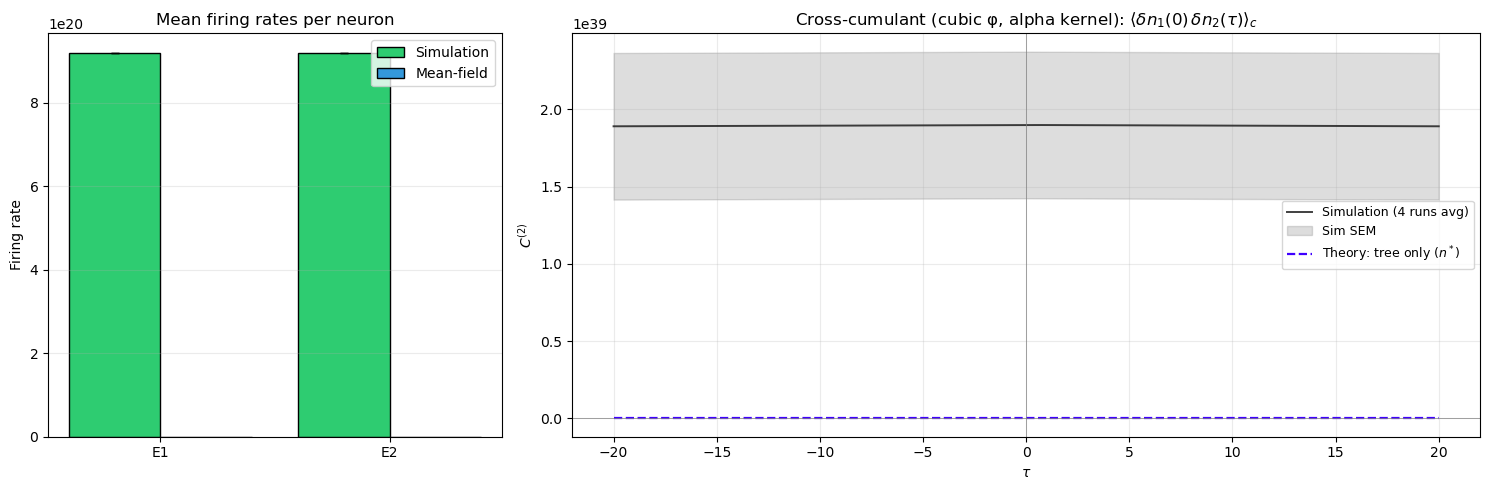

In [12]:
# Per-loop-order cumulative theory curves.
# C_by_ell[ell] is the contribution from exactly that loop order
# (ell=0 is tree).  Cumulative theory up to order N is
# sum_{ell=0..N} C_by_ell[ell].
_max_ell_present = max((e for e in C_by_ell.keys()), default=0)
_C_cumulative = {}  # ell → cumulative C(τ) summed up to that order
_running = np.zeros_like(C_theory_total)
for ell in range(0, _max_ell_present + 1):
    if ell in C_by_ell:
        _running = _running + C_by_ell[ell].real
    _C_cumulative[ell] = _running.copy()

# Per-order RATE correction at τ-grid midpoint (for k=1).
if k == 1:
    _mid = len(tau_grid_th) // 2
    _rate_cum_per_order = {
        ell: float(_C_cumulative[ell][_mid])
        for ell in range(0, _max_ell_present + 1)
    }

# Colour ramp for cumulative curves: tree dark blue → highest-order red.
_COLOURS = ['#3F00FF', '#1F9FCC', '#E67E22', '#E74C3C', '#8E44AD', '#16A085']

def _label_for_order(ell):
    if ell == 0:
        return 'Theory: tree only ($n^*$)'
    parts = ['tree'] + [f'{e}-loop' for e in range(1, ell + 1)]
    return 'Theory: ' + ' + '.join(parts)

if k == 1:
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    x = np.arange(N)
    n_theory_bars = _max_ell_present + 1  # tree + each loop order
    n_total_bars = 1 + n_theory_bars      # +1 for sim
    width = 0.8 / n_total_bars
    offsets = (np.arange(n_total_bars) - (n_total_bars - 1) / 2) * width
    tick_labels = []
    for pname, (start, size) in pop_offsets.items():
        for i in range(size):
            tick_labels.append(f'{pname}{i+1}')

    # Sim bar (leftmost).
    ax.bar(x + offsets[0], rate_sim_mean, width,
           yerr=rate_sim_sem, capsize=3,
           label='Simulation', color='#2ECC71', edgecolor='black')

    # Cumulative theory bars (one per loop order).
    for i, ell in enumerate(range(0, _max_ell_present + 1)):
        rates = nstar_flat.copy()
        # For the target external field, add the cumulative correction
        # up to order ell.  Tree (ell=0) is just n*; loops add on top.
        if ell >= 1:
            rates[pop_indices[0]] = (
                float(nstar_flat[pop_indices[0]])
                + _rate_cum_per_order[ell] - _rate_cum_per_order[0]
            )
        ax.bar(x + offsets[i + 1], rates, width,
               label=_label_for_order(ell),
               color=_COLOURS[ell % len(_COLOURS)],
               edgecolor='black', alpha=0.85)

    if _max_ell_present >= 1:
        ax.annotate(
            f'loops computed for '
            f'{external_fields[0][0]}{external_fields[0][1]}',
            xy=(pop_indices[0], rate_sim_mean[pop_indices[0]] * 1.1),
            xytext=(pop_indices[0] + 0.2,
                    rate_sim_mean[pop_indices[0]] * 1.3),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#555'),
        )
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel('Firing rate')
    field_a = external_fields[0]
    ax.set_title(f'k=1 rate (cubic φ, alpha kernel), max_ell={max_ell}, '
                 f'loop target: {field_a[0]}_{field_a[1]}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={'width_ratios': [1, 2]})

    ax_bar = axes[0]
    x = np.arange(N)
    width = 0.4
    ax_bar.bar(x - width/2, rate_sim_mean, width,
               yerr=rate_sim_sem, capsize=3,
               label='Simulation', color='#2ECC71', edgecolor='black')
    ax_bar.bar(x + width/2, nstar_flat, width,
               label='Mean-field', color='#3498DB', edgecolor='black')
    ax_bar.set_xticks(x)
    tick_labels = []
    for pname, (start, size) in pop_offsets.items():
        for i in range(size):
            tick_labels.append(f'{pname}{i+1}')
    ax_bar.set_xticklabels(tick_labels)
    ax_bar.set_ylabel('Firing rate')
    ax_bar.set_title('Mean firing rates per neuron')
    ax_bar.legend()
    ax_bar.grid(True, axis='y', alpha=0.25)

    ax = axes[1]
    ax.plot(tau_sim_grid, C_sim_mean, color='#1f1f1f', linewidth=1.4,
            label=f'Simulation ({N_RUNS} runs avg)', alpha=0.85)
    ax.fill_between(tau_sim_grid,
                    C_sim_mean - C_sim_sem,
                    C_sim_mean + C_sim_sem,
                    color='#1f1f1f', alpha=0.15, label='Sim SEM')
    # Per-order cumulative curves.
    for ell in range(0, _max_ell_present + 1):
        style = '--' if ell == 0 else '-'
        ax.plot(tau_grid_th, _C_cumulative[ell],
                color=_COLOURS[ell % len(_COLOURS)],
                linewidth=1.6, linestyle=style,
                label=_label_for_order(ell))
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    field_a, field_b = external_fields
    ax.set_xlabel(r'$\tau$')
    ax.set_ylabel(r'$C^{(2)}$')
    ax.set_title(f'Cross-cumulant (cubic φ, alpha kernel): '
                 f'$\\langle\\delta {field_a[0]}_{{{field_a[1]}}}(0)\\,'
                 f'\\delta {field_b[0]}_{{{field_b[1]}}}(\\tau)\\rangle_c$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()


## 7. Numerical residual

**k = 2**: tree-only vs tree+loop residual.

**k = 1**: rate-shift residual.

In [13]:
if k == 1:
    i_tgt   = pop_indices[0]
    r_sim   = float(rate_sim_mean[i_tgt])
    r_sem   = float(rate_sim_sem[i_tgt])

    # Per-cumulative-order rate.
    _max_ell_present = max((e for e in C_by_ell.keys()), default=0)
    _mid = len(tau_grid_th) // 2
    rate_at_order = {}
    running = float(nstar_flat[i_tgt])
    for ell in range(0, _max_ell_present + 1):
        if ell == 0:
            rate_at_order[ell] = running   # tree = n*
        else:
            running = (
                running
                + float(C_by_ell[ell].real[_mid])
            )
            rate_at_order[ell] = running

    print(f'Target field          : {external_fields[0]} '
          f'(flat sim index {i_tgt})')
    print(f'Sim rate              : {r_sim:.6f}  (SEM {r_sem:.2e})')
    print()
    print('Per-order cumulative theory rate:')
    for ell in range(0, _max_ell_present + 1):
        suffix = '' if ell == 0 else f' (= tree + 1..{ell}-loop)'
        print(f'  ell={ell}{suffix:<24}: {rate_at_order[ell]:.6f}'
              f'   (residual sim - theory = '
              f'{r_sim - rate_at_order[ell]:+.4e}, '
              f'{(r_sim - rate_at_order[ell]) / r_sem:+.2f}σ)')
    print()
    if _max_ell_present >= 1:
        tree_resid = r_sim - rate_at_order[0]
        full_resid = r_sim - rate_at_order[_max_ell_present]
        delta = abs(tree_resid) - abs(full_resid)
        sign = 'shrank the gap' if delta > 0 else 'grew the gap'
        print(f'|residual| change tree → full: {delta:+.4e} '
              f'({sign})')
else:
    _max_ell_present = max((e for e in C_by_ell.keys()), default=0)
    C_total_on_sim_grid = np.interp(tau_sim_grid, tau_grid_th,
                                    C_theory_total)
    residual            = C_sim_mean - C_total_on_sim_grid

    peak        = max(abs(C_sim_mean.max()), abs(C_sim_mean.min()))
    rms_rel     = float(np.sqrt(np.mean(residual**2)) / peak)
    max_abs_rel = float(np.max(np.abs(residual)) / peak)
    sem_peak    = float(C_sim_sem[np.argmax(np.abs(C_sim_mean))])

    print(f'Sim peak |C|             : {peak:+.4e}')
    print(f'Residual RMS / peak (tree + all loops) : {rms_rel:.3%}')
    print(f'Residual max / peak                    : {max_abs_rel:.3%}')
    print(f'Sim SEM at peak                        : {sem_peak:+.3e} '
          f'({sem_peak / peak:.3%} of peak)')

    # Per-order cumulative residual RMS.
    if _max_ell_present >= 1:
        print()
        print('Per-order residual RMS / peak (sim − cumulative theory):')
        running = np.zeros_like(C_theory_total)
        for ell in range(0, _max_ell_present + 1):
            if ell in C_by_ell:
                running = running + C_by_ell[ell].real
            C_on_sim = np.interp(tau_sim_grid, tau_grid_th, running)
            r = C_sim_mean - C_on_sim
            r_rms = float(np.sqrt(np.mean(r**2)) / peak)
            suffix = '' if ell == 0 else f' (cumulative)'
            print(f'  ell={ell}{suffix:<14}: {r_rms:.3%}')


Sim peak |C|             : +1.8983e+39
Residual RMS / peak (tree + all loops) : 99.776%
Residual max / peak                    : 100.000%
Sim SEM at peak                        : +4.744e+38 (24.988% of peak)


## 8. (Optional) Save outputs

In [14]:
from pipeline import save_npz, save_csv

SAVE = False

if SAVE:
    out_dir = '../pipeline_outputs/singlepop_quad_sim_compare'
    os.makedirs(out_dir, exist_ok=True)
    leg_tag = '_'.join(f'{ef[0]}{ef[1]}' for ef in external_fields)
    slug = f'singlepop_quad_{leg_tag}_k{k}_ell{max_ell}'

    sim_extra = {
        'rates_sim_mean'  : rate_sim_mean,
        'rates_sim_sem'   : rate_sim_sem,
        'sim_N_RUNS'      : np.array([N_RUNS], dtype=int),
        'sim_T'           : np.array([T_sim]),
        'sim_dt'          : np.array([dt_sim]),
        'sim_dt_bin'      : np.array([dt_bin]),
        'sim_variant'     : np.array(['quad_no_reset']),
        'pop_offsets_keys': np.array(list(pop_offsets.keys())),
        'pop_offsets_vals': np.array([list(v) for v in pop_offsets.values()]),
    }
    if k >= 2:
        sim_extra.update({
            'tau_grid_sim' : tau_sim_grid,
            'C_sim_mean'   : C_sim_mean,
            'C_sim_sem'    : C_sim_sem,
        })
    npz_path = f'{out_dir}/{slug}.npz'
    csv_path = f'{out_dir}/{slug}.csv'
    save_npz(th, npz_path, extra=sim_extra)
    save_csv(th, csv_path)
    print(f'Saved: {npz_path}')
    print(f'Saved: {csv_path}')
else:
    print('SAVE=False — outputs not written.  Flip the flag above to save.')

SAVE=False — outputs not written.  Flip the flag above to save.


## Summary

Single-population (size-2) Hawkes process with a **cubic** transfer $\phi(v)=a\,v^3$ and an
**alpha-kernel** synaptic filter $g(t)=(t/\tau_g^2)\,e^{-t/\tau_g}\,H(t)$ (double Fourier poles),
no spike reset. The nonzero $\phi''(v^*)=6av^*$ activates a cubic vertex, so the 1-loop
correction to $C^{(2)}(\tau)$ (or the rate) is the physics compared against the numba simulator.

### Notes specific to cubic φ without reset

- **Nonzero φ curvature.**  With $\phi(v) = a\,v^3$, $\phi''(v^*) = 6 a v^*$,
  so the cubic vertex $-a\,\tilde n\,\delta v\,\delta v$ at bigrade
  $(1,2)$ is present.  This is the canonical source of 1-loop
  corrections in cubic-Hawkes — turn on `max_ell = 1` to see them.
- **MF closure** $n^* = a \cdot v^{*3}$ should hold to floating-point
  precision at the saddle (printed in section 4).
- **No reset.**  Voltage drifts continuously through spike events
  on the sim side, and the action contains no $+\tau v n$ term
  on the theory side.  If you see a $(1, 2)$ vertex with coeff
  $\propto \tau$ in the §3.5 diagnostic, the theory file has a
  reset term it shouldn't.
- **Single-pop parameter naming.**  Theory uses bare `tau`, `a`,
  `Em`, `w`, `taug` (no population suffix).  `build_sim_arrays`
  resolves them via the `name_or_suffixed` fallback.